In [15]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv("C:\\Users\\kadir\\sandy\\XAI-DRIVEN-SOIL-FERTILITY-PREDICTION-A-DATA-CENTRIC-APPROACH-\\dataset1.csv")


# Display the first few rows of the dataset
print(data.head())

# Prepare features and target variable
X = data.drop('Fertility', axis=1)  # Features
y = data['Fertility']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and split successfully!")



     N    P    K    pH    EC    OC     S    Zn    Fe    Cu    Mn     B  \
0  138  8.6  560  7.46  0.62  0.70   5.9  0.24  0.31  0.77  8.71  0.11   
1  213  7.5  338  7.62  0.75  1.06  25.4  0.30  0.86  1.54  2.89  2.29   
2  163  9.6  718  7.59  0.51  1.11  14.3  0.30  0.86  1.57  2.70  2.03   
3  157  6.8  475  7.64  0.58  0.94  26.0  0.34  0.54  1.53  2.65  1.82   
4  270  9.9  444  7.63  0.40  0.86  11.8  0.25  0.76  1.69  2.43  2.26   

   Fertility  
0          0  
1          0  
2          0  
3          0  
4          1  
Data loaded and split successfully!


In [ ]:

pip install scikit_learn



   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.7 MB 2.1 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.7 MB 2.0 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.7 MB 1.9 MB/s eta 0:00:04
   --------- ------------------------------ 2.1/8.7 MB 2.0 MB/s eta 0:00:04
   ------------- -------------------------- 2.9/8.7 MB 2.3 MB/s eta 0:00:03
   ---------------- ----------------------- 3.7/8.7 MB 2.5 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.7 MB 2.4 MB/s eta 0:00:02
   ---------------------- ----------------- 5.0/8.7 MB 2.6 MB/s eta 0:00:02
   --------------------------- ------------ 6.0/8.7 MB 2.9 MB/s eta 0:00:01
   --------------------------------- ------ 7.3/8.7 MB 3.2 MB/s eta 0:00:01
   ------------------------------


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest Classifier with class weights to handle imbalance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Print classification report with zero_division set to avoid warnings
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=1))


Model Accuracy: 99.08%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       157
           1       1.00      0.98      0.99       179
           2       1.00      1.00      1.00        98

    accuracy                           0.99       434
   macro avg       0.99      0.99      0.99       434
weighted avg       0.99      0.99      0.99       434



In [12]:
import shap
import matplotlib.pyplot as plt

# Create an explainer object for the Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)

# Loop through each class to plot SHAP summary plots
for class_idx in range(len(shap_values)):
    print(f"SHAP summary plot for class {class_idx}")
    
    # Use the detailed SHAP summary plot for each class
    # Ensure that the shape of shap_values and X_test match
    if shap_values[class_idx].shape[0] == X_test.shape[0]:
        shap.summary_plot(shap_values[class_idx], X_test)
    else:
        print(f"Shape mismatch for class {class_idx}: SHAP values shape {shap_values[class_idx].shape} vs. X_test shape {X_test.shape}")


SHAP summary plot for class 0
Shape mismatch for class 0: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 1
Shape mismatch for class 1: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 2
Shape mismatch for class 2: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 3
Shape mismatch for class 3: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 4
Shape mismatch for class 4: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 5
Shape mismatch for class 5: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 6
Shape mismatch for class 6: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 7
Shape mismatch for class 7: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 8
Shape mismatch for class 8: SHAP values shape (12, 3) vs. X_test shape (434, 12)
S

In [11]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import joblib

# ----------------------------
# 1. Load dataset
# ----------------------------
data = pd.read_csv("C:/Users/kadir/sandy/XAI-DRIVEN-SOIL-FERTILITY-PREDICTION-A-DATA-CENTRIC-APPROACH-/dataset1.csv")

# Replace 'fertility' with your actual target column name
X = data.drop(columns=['Fertility'])
y = data['Fertility']

# ----------------------------
# 2. Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------------------
# 3. Load your saved model
# ----------------------------
rf_model = joblib.load(
    "C:/Users/kadir/sandy/XAI-DRIVEN-SOIL-FERTILITY-PREDICTION-A-DATA-CENTRIC-APPROACH-/soil_fertility_rf_model.pkl"
)

# ----------------------------
# 4. SHAP Analysis
# ----------------------------
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

for class_idx in range(len(shap_values)):
    print(f"SHAP summary plot for class {class_idx}")
    
    if shap_values[class_idx].shape[0] == X_test.shape[0]:
        shap.summary_plot(shap_values[class_idx], X_test, show=True)
    else:
        print(f"Shape mismatch for class {class_idx}: SHAP values shape {shap_values[class_idx].shape} vs. X_test shape {X_test.shape}")


c:\Users\kadir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\kadir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


SHAP summary plot for class 0
Shape mismatch for class 0: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 1
Shape mismatch for class 1: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 2
Shape mismatch for class 2: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 3
Shape mismatch for class 3: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 4
Shape mismatch for class 4: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 5
Shape mismatch for class 5: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 6
Shape mismatch for class 6: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 7
Shape mismatch for class 7: SHAP values shape (12, 3) vs. X_test shape (434, 12)
SHAP summary plot for class 8
Shape mismatch for class 8: SHAP values shape (12, 3) vs. X_test shape (434, 12)
S

In [44]:
import shap
from IPython.display import display, HTML

# Load or define your model before this step!

# Compute SHAP explainer and values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Predict on the test set
predictions = model.predict(X_test)

# Get predicted class for first sample
pred_class = predictions[0]

# Extract SHAP values and base value for that class and instance
shap_val = shap_values[pred_class][0]
base_val = explainer.expected_value[pred_class]

# Get the features of the first test sample
features = X_test.iloc[0]

# Initialize JS for visualization
shap.initjs()

# Generate the SHAP force plot as HTML
shap_html = shap.plots.force(base_val, shap_val, features, matplotlib=False)

# Display interactive plot in Jupyter Notebook
display(HTML(shap_html.html()))


DimensionError: Length of features is not equal to the length of shap_values!

In [47]:
shap_val = shap_values[pred_class][0]  # This should be shape (12,)


In [48]:
print(type(shap_values))            # Should be list
print(len(shap_values))             # Should be number of classes, e.g. 3
print(shap_values[0].shape)         # Should be (num_samples, num_features) e.g. (N, 12)

print(shap_values[pred_class].shape)  # Should be (num_samples, num_features)
print(shap_values[pred_class][0].shape)  # Should be (num_features,) i.e. (12,)


<class 'numpy.ndarray'>
434
(12, 3)
(12, 3)
(3,)


In [49]:
predictions = model.predict(X_test)
pred_class = predictions[0]

# SHAP values for predicted class, first sample
shap_val = shap_values[pred_class][0]

print("shap_val shape:", shap_val.shape)  # Expect (12,)

features = X_test.iloc[0]

shap.initjs()
shap_html = shap.plots.force(
    explainer.expected_value[pred_class],
    shap_val,
    features,
    matplotlib=False
)

from IPython.display import display, HTML
display(HTML(shap_html.html()))


shap_val shape: (3,)


DimensionError: Length of features is not equal to the length of shap_values!

In [50]:
print("shap_val:", shap_val)
print("len(shap_val):", len(shap_val))  # Should be 12 to match features


shap_val: [-0.1999123   0.39094703 -0.19103474]
len(shap_val): 3


In [51]:
shap_val = shap_values[0][0]  # this might be 3 features, not 12


In [52]:
print(type(shap_values))  # Should be list
print(f"Number of classes: {len(shap_values)}")

for i, val in enumerate(shap_values):
    print(f"Class {i} shape: {val.shape}")


<class 'numpy.ndarray'>
Number of classes: 434
Class 0 shape: (12, 3)
Class 1 shape: (12, 3)
Class 2 shape: (12, 3)
Class 3 shape: (12, 3)
Class 4 shape: (12, 3)
Class 5 shape: (12, 3)
Class 6 shape: (12, 3)
Class 7 shape: (12, 3)
Class 8 shape: (12, 3)
Class 9 shape: (12, 3)
Class 10 shape: (12, 3)
Class 11 shape: (12, 3)
Class 12 shape: (12, 3)
Class 13 shape: (12, 3)
Class 14 shape: (12, 3)
Class 15 shape: (12, 3)
Class 16 shape: (12, 3)
Class 17 shape: (12, 3)
Class 18 shape: (12, 3)
Class 19 shape: (12, 3)
Class 20 shape: (12, 3)
Class 21 shape: (12, 3)
Class 22 shape: (12, 3)
Class 23 shape: (12, 3)
Class 24 shape: (12, 3)
Class 25 shape: (12, 3)
Class 26 shape: (12, 3)
Class 27 shape: (12, 3)
Class 28 shape: (12, 3)
Class 29 shape: (12, 3)
Class 30 shape: (12, 3)
Class 31 shape: (12, 3)
Class 32 shape: (12, 3)
Class 33 shape: (12, 3)
Class 34 shape: (12, 3)
Class 35 shape: (12, 3)
Class 36 shape: (12, 3)
Class 37 shape: (12, 3)
Class 38 shape: (12, 3)
Class 39 shape: (12, 3)
Cla

In [53]:
print(np.array(shap_values).shape)


(434, 12, 3)


In [54]:
import shap
print(shap.__version__)


0.48.0


In [55]:
shap_values = explainer(X_test)  # This returns a shap.Explanation object


In [56]:
# Get the explanation object
shap_values = explainer(X_test)

# Check the shape and type of values
print(type(shap_values))  # Should be shap.Explanation
print(shap_values.values.shape)  # (samples, classes, features)

# Let's say you want the first sample and the predicted class index (0,1,2)
sample_idx = 0
pred_class = 0  # change as needed

# Extract base value and SHAP values for this sample and class
base_value = shap_values.base_values[sample_idx, pred_class]
shap_val = shap_values.values[sample_idx, pred_class, :]
features = X_test.iloc[sample_idx]

# Now plot force plot
shap.initjs()
shap.plots.force(base_value, shap_val, features)


<class 'shap._explanation.Explanation'>
(434, 12, 3)


DimensionError: Length of features is not equal to the length of shap_values!

In [57]:
sample_idx = 0       # the sample to explain
class_idx = 0        # the class index for which you want explanation

# base value for that sample and class
base_val = shap_values.base_values[sample_idx, class_idx]

# shap values for that sample and class (length = number of features, here 3)
shap_val = shap_values.values[sample_idx, class_idx]

# feature values of the sample (length = number of features)
features = X_test.iloc[sample_idx]

# plot force plot
shap.initjs()
shap.plots.force(base_val, shap_val, features)


DimensionError: Length of features is not equal to the length of shap_values!

In [10]:
print(data.columns)


Index(['N', 'P', 'K', 'pH', 'EC', 'OC', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B',
       'Fertility'],
      dtype='object')


In [41]:
import shap
print(shap.__version__)


0.48.0


In [39]:
pip install --upgrade shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import joblib
rf_model = joblib.load("soil_fertility_rf_model.pkl")


c:\Users\kadir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\kadir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [33]:
pip install --upgrade numpy==2.1.0

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 1.4 MB/s eta 0:00:09
   - -------------------------------------- 0.5/12.6 MB 1.4 MB/s eta 0:00:09
   --- ------------------------------------ 1.0/12.6 MB 1.3 MB/s eta 0:00:10
   --- ------------------------------------ 1.0/12.6 MB 1.3 MB/s eta 0:00:10
   ---- ----------------------------------- 1.3/12.6 MB 1.1 MB/s eta 0:00:11
   ----- ---------------------------------- 1.8/12.6 MB 1.2 MB/s eta 0:00:09
   ------ --------------------------------- 2.1/12.6 MB 1.2 MB/s eta 0:00:09
   ------- -------------------------------- 2.4/12.6 MB 1.2 MB/s eta 0:00:09
   -------- ------------------------------- 2.6/12.6 MB 1.3 MB/s eta 0:00:08
   -------- ------------------------------- 2.6/12.6 MB 1.3 MB/s eta 0:00:08
   --------- ------------------------------ 2.9/12.6 MB 1.2 MB/s eta 0:00:09
   ----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# Print shapes for verification
print(f"Shape of X_test: {X_test.shape}")
print(f"Number of classes: {len(shap_values)}")

for class_idx in range(len(shap_values)):
    print(f"Shape of SHAP values for class {class_idx}: {shap_values[class_idx].shape}")


Shape of X_test: (434, 12)
Number of classes: 434
Shape of SHAP values for class 0: (12, 3)
Shape of SHAP values for class 1: (12, 3)
Shape of SHAP values for class 2: (12, 3)
Shape of SHAP values for class 3: (12, 3)
Shape of SHAP values for class 4: (12, 3)
Shape of SHAP values for class 5: (12, 3)
Shape of SHAP values for class 6: (12, 3)
Shape of SHAP values for class 7: (12, 3)
Shape of SHAP values for class 8: (12, 3)
Shape of SHAP values for class 9: (12, 3)
Shape of SHAP values for class 10: (12, 3)
Shape of SHAP values for class 11: (12, 3)
Shape of SHAP values for class 12: (12, 3)
Shape of SHAP values for class 13: (12, 3)
Shape of SHAP values for class 14: (12, 3)
Shape of SHAP values for class 15: (12, 3)
Shape of SHAP values for class 16: (12, 3)
Shape of SHAP values for class 17: (12, 3)
Shape of SHAP values for class 18: (12, 3)
Shape of SHAP values for class 19: (12, 3)
Shape of SHAP values for class 20: (12, 3)
Shape of SHAP values for class 21: (12, 3)
Shape of SHAP 

In [14]:
import shap
import matplotlib.pyplot as plt

# Create an explainer object for the Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)

# Print shapes for verification
print(f"Shape of X_test: {X_test.shape}")
print(f"Number of classes: {len(shap_values)}")

# Ensure dimensions match
num_features = X_test.shape[1]
for idx in range(len(shap_values)):
    print(f"Shape of SHAP values for class {idx}: {shap_values[idx].shape}")
    if shap_values[idx].shape[1] != num_features:
        # Adjust SHAP values to match the number of features
        shap_values[idx] = shap_values[idx][:, :num_features]

# Ensure feature names are correct
feature_names = X_test.columns.tolist()

# Select a sample index and class index
sample_idx = 0  # Change the index to any other sample you want to visualize
class_idx = 0   # Change this to the class you want to visualize

# Create a force plot for the given sample and class
try:
    shap.force_plot(
        explainer.expected_value[class_idx],
        shap_values[class_idx][sample_idx],
        X_test.iloc[sample_idx],
        feature_names=feature_names,
        matplotlib=True
    )
    plt.show()
except Exception as e:
    print(f"An error occurred: {e}")


Shape of X_test: (434, 12)
Number of classes: 434
Shape of SHAP values for class 0: (12, 3)
Shape of SHAP values for class 1: (12, 3)
Shape of SHAP values for class 2: (12, 3)
Shape of SHAP values for class 3: (12, 3)
Shape of SHAP values for class 4: (12, 3)
Shape of SHAP values for class 5: (12, 3)
Shape of SHAP values for class 6: (12, 3)
Shape of SHAP values for class 7: (12, 3)
Shape of SHAP values for class 8: (12, 3)
Shape of SHAP values for class 9: (12, 3)
Shape of SHAP values for class 10: (12, 3)
Shape of SHAP values for class 11: (12, 3)
Shape of SHAP values for class 12: (12, 3)
Shape of SHAP values for class 13: (12, 3)
Shape of SHAP values for class 14: (12, 3)
Shape of SHAP values for class 15: (12, 3)
Shape of SHAP values for class 16: (12, 3)
Shape of SHAP values for class 17: (12, 3)
Shape of SHAP values for class 18: (12, 3)
Shape of SHAP values for class 19: (12, 3)
Shape of SHAP values for class 20: (12, 3)
Shape of SHAP values for class 21: (12, 3)
Shape of SHAP 

In [16]:

from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Get the best model from Grid Search
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_best = best_rf_model.predict(X_test)

# Evaluate the best model
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Best Model Accuracy: {accuracy_best * 100:.2f}%")
print("\nBest Model Classification Report:\n", classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best Score: 0.9780879878729323
Best Model Accuracy: 99.08%

Best Model Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       157
           1       1.00      0.98      0.99       179
           2       1.00      1.00      1.00        98

    accuracy                           0.99       434
   macro avg       0.99      0.99      0.99       434
weighted avg       0.99      0.99      0.99       434



Visualization Improvements

Shape of X_test: (434, 12)
SHAP values shape: (434, 12, 3)
Classes: [0 1 2]
SHAP summary plot for class 0


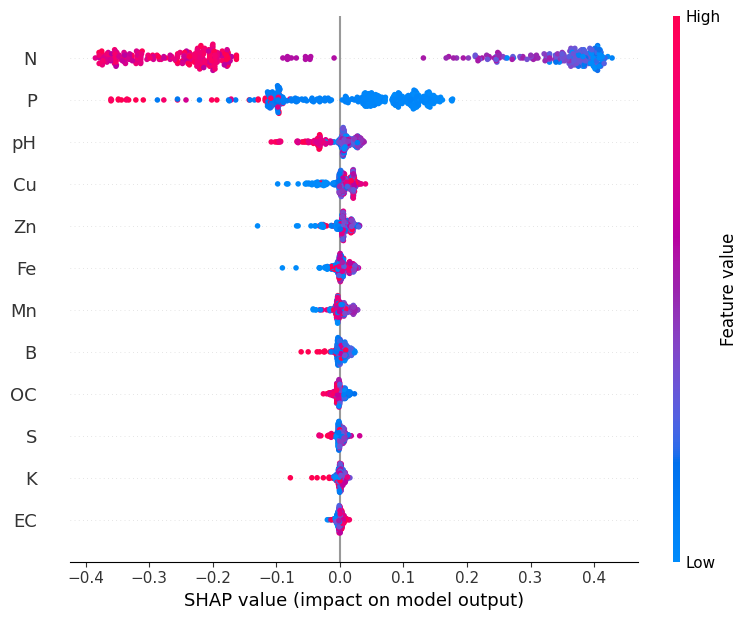

SHAP summary plot for class 1


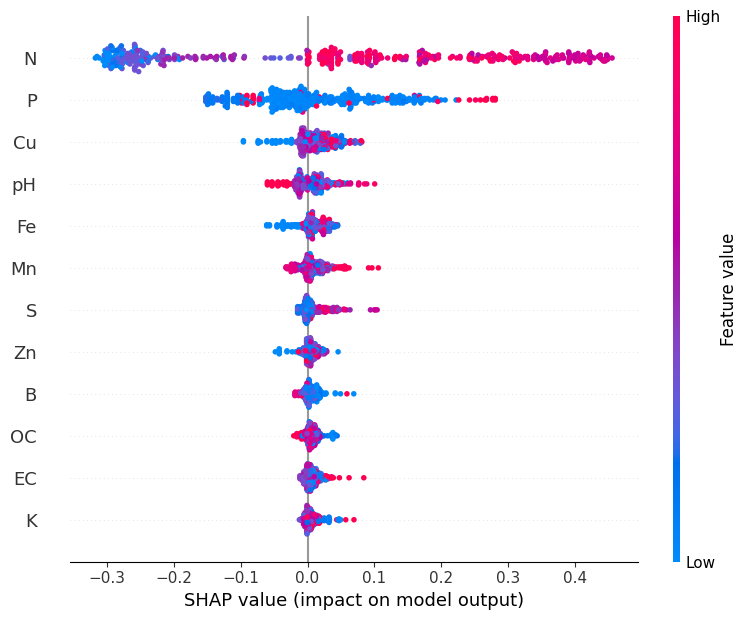

SHAP summary plot for class 2


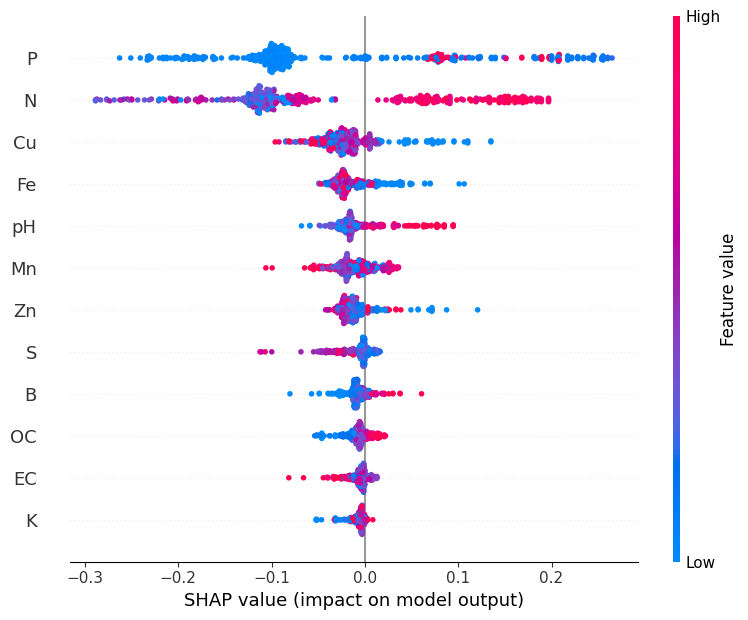

In [31]:
# # Print shapes for verification
# print(f"Shape of X_test: {X_test.shape}")
# print(f"Number of classes: {len(shap_values)}")

# # Print the shapes of SHAP values for each class
# for class_idx in range(len(shap_values)):
#     print(f"Shape of SHAP values for class {class_idx}: {shap_values[class_idx].shape}")

# # Ensure that the SHAP values dimensions match with features
# num_features = X_test.shape[1]
# for idx in range(len(shap_values)):
#     if shap_values[idx].shape[1] != num_features:
#         # Adjust SHAP values to match the number of features
#         shap_values[idx] = shap_values[idx][:, :num_features]
#         print(f"Adjusted SHAP values for class {idx}")

# # Check feature names
# feature_names = X_test.columns.tolist()

# # Ensure the features match
# if len(feature_names) != X_test.shape[1]:
#     print("Feature names do not match the number of columns in X_test")

# # Detailed SHAP summary plot for individual features
# try:
#     shap.summary_plot(
#         shap_values[1],  # Choose the appropriate class index
#         X_test,
#         feature_names=feature_names,
#         plot_type="dot"
#     )
# except Exception as e:
#     print(f"An error occurred: {e}")

# plt.show()

# Correct way for multi-class SHAP
print("Shape of X_test:", X_test.shape)
print("SHAP values shape:", shap_values.shape)  # (n_samples, n_features, n_classes)
print("Classes:", rf_model.classes_)

feature_names = X_test.columns.tolist()

# Plot SHAP values for each class
for class_idx, class_label in enumerate(rf_model.classes_):
    print(f"SHAP summary plot for class {class_label}")
    shap.summary_plot(
        shap_values[:, :, class_idx],  # Correct slice
        X_test,
        feature_names=feature_names,
        plot_type="dot"
    )



In [33]:
# Map target numbers to fertility categories
fertility_labels = {0: "Low", 1: "Medium", 2: "High"}

# Make prediction
prediction = model.predict(input_data)
prediction_proba = model.predict_proba(input_data)

# Get predicted class and label
predicted_class = prediction[0]
predicted_label = fertility_labels[predicted_class]

# Show result
st.success(f"Predicted Soil Fertility: {predicted_label}")

# Show prediction probabilities for all classes
st.write("### Prediction Probabilities:")
for i, prob in enumerate(prediction_proba[0]):
    st.write(f"- {fertility_labels[i]}: {prob*100:.2f}%")


NameError: name 'input_data' is not defined

In [18]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


SHAP summary plot for class: 0


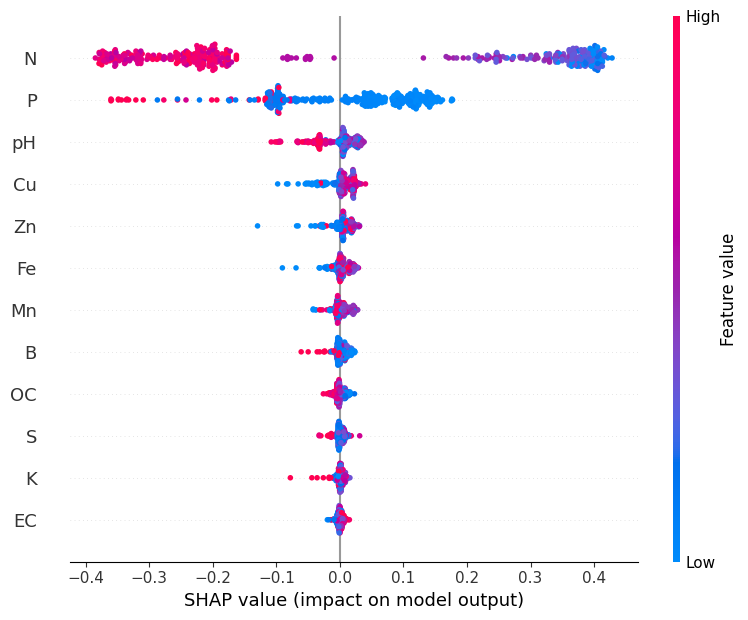

SHAP summary plot for class: 1


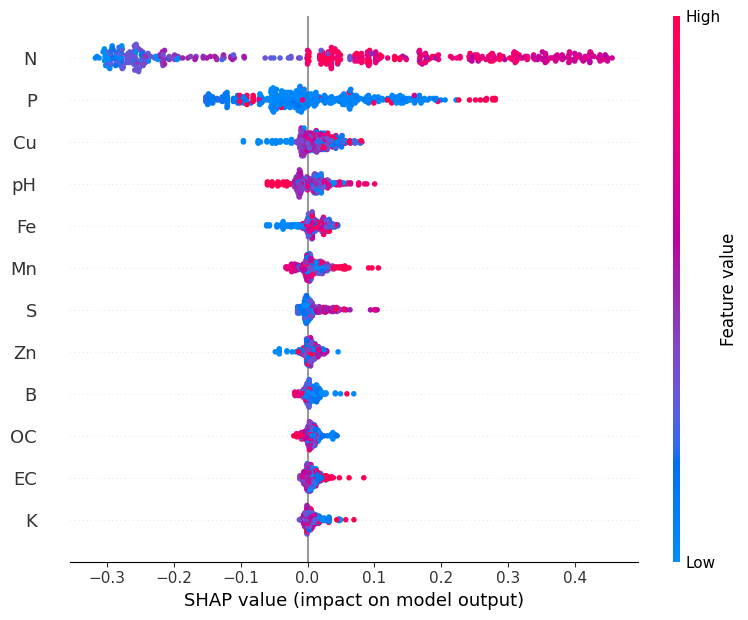

SHAP summary plot for class: 2


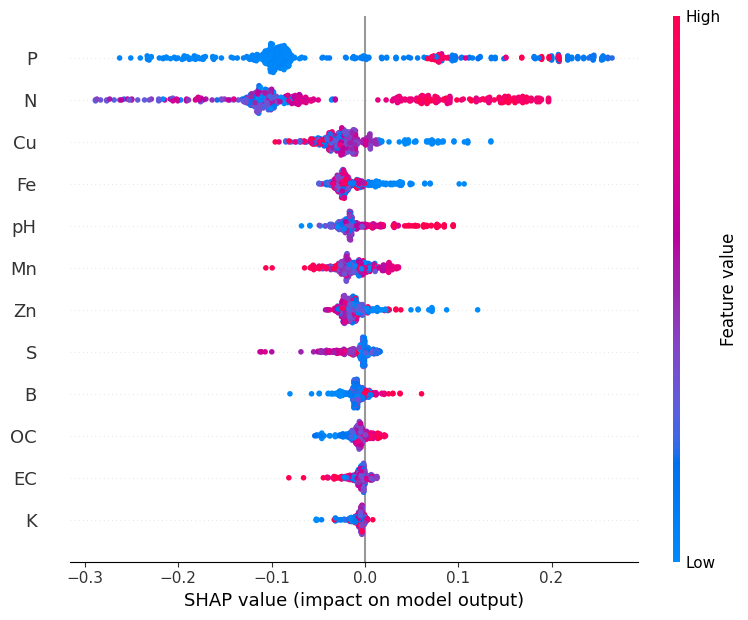

In [28]:
# Iterate over each class in your model
for class_idx, class_label in enumerate(rf_model.classes_):
    print(f"SHAP summary plot for class: {class_label}")
    shap.summary_plot(
        shap_values[:, :, class_idx],  # select the correct class slice
        X_test,
        feature_names=feature_names,
        plot_type="dot"
    )


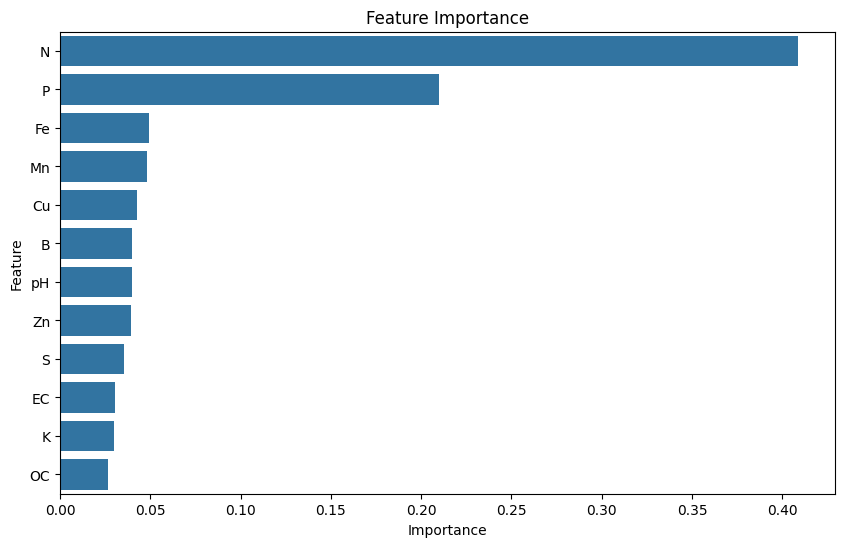

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances
importances = best_rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importance')
plt.show()


Confusion Matrix: Plot the confusion matrix to visualize the performance across different classes

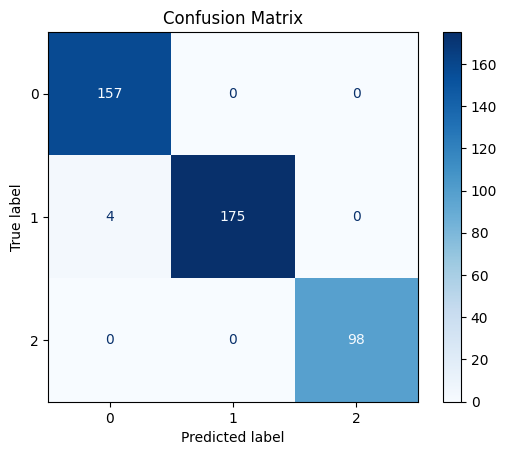

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


C:\Users\kadir\AppData\Local\Temp\ipykernel_21724\2196895946.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


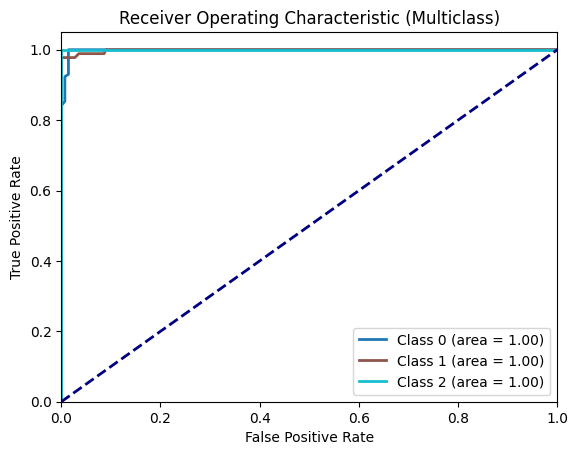

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assuming best_rf_model and X_test are already defined

# Binarize the output
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], best_rf_model.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure()
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2, label=f'Class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Multiclass)')
plt.legend(loc='lower right')
plt.show()


In [22]:
import joblib

# Load the trained model
model = joblib.load('soil_fertility_rf_model.pkl')  # Ensure this path is correct

# Check feature names
print("Model Feature Names:", model.feature_names_in_)


Model Feature Names: ['N' 'P' 'K' 'pH' 'EC' 'OC' 'S' 'Zn' 'Fe' 'Cu' 'Mn' 'B']


c:\Users\kadir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\kadir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
